In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from scipy import stats

warnings.filterwarnings('ignore')

In [3]:
# ============================================
# 1. SETUP AND SEEDS
# ============================================

# Set global random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
# ============================================
# 2. DATA LOADING AND PREPARATION
# ============================================

# Load data
df = pd.read_csv('STOXX50.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Select closing price series
ts = df['STOXX50_Close'].ffill()

# Split into train/test
test_size = 30
train_ts = ts[:-test_size]
test_ts = ts[-test_size:]

print("Training set:", len(train_ts), "days")
print("Test set:", len(test_ts), "days")


Training set: 4441 days
Test set: 30 days


In [ ]:
# ============================================
# 3. ARIMA COMPONENT
# ============================================

print("\n" + "="*60)
print("ARIMA COMPONENT")
print("="*60)

# Determine differencing order
def check_stationarity(series):
    result = adfuller(series.dropna(), autolag='AIC')
    return result

adf_result = check_stationarity(train_ts)
p_value = adf_result[1]

if p_value <= 0.05:
    d = 0
else:
    first_diff = train_ts.diff().dropna()
    adf_result_first = check_stationarity(first_diff)
    p_first = adf_result_first[1]
    
    if p_first <= 0.05:
        d = 1
    else:
        d = 1  # Default to first difference

print(f"Differencing order: d = {d}")

# Find best ARIMA model
p_range = range(0, 6)
q_range = range(0, 6)
results = []

for p in p_range:
    for q in q_range:
        if d == 0 and p == 0 and q == 0:
            continue
            
        order = (p, d, q)
        
        try:
            model = ARIMA(train_ts, order=order)
            model_fit = model.fit()
            
            results.append({
                'p': p,
                'd': d,
                'q': q,
                'aicc': model_fit.aicc,
            })
            
        except Exception as e:
            continue

results_df = pd.DataFrame(results)
if len(results_df) > 0:
    results_df = results_df.sort_values('aicc').reset_index(drop=True)
    best_arima = results_df.iloc[0]
    best_p = int(best_arima['p'])
    best_q = int(best_arima['q'])
    
    print(f"Best ARIMA model: ARIMA({best_p}, {d}, {best_q})")
else:
    best_p, best_q = 1, 1
    print("Using default ARIMA(1,d,1)")

# Fit ARIMA on training data
arima_model = ARIMA(train_ts, order=(best_p, d, best_q))
arima_fit = arima_model.fit()

# Get ARIMA predictions and residuals
arima_train_pred = arima_fit.fittedvalues
arima_residuals = train_ts - arima_train_pred
arima_residuals.iloc[0] = 0
arima_residuals = arima_residuals.dropna()

print(f"ARIMA residuals calculated")
print(f"ARIMA residuals stats - Mean: {arima_residuals.mean():.4f}, Std: {arima_residuals.std():.4f}")



ARIMA COMPONENT
Differencing order: d = 1
Best ARIMA model: ARIMA(3, 1, 2)
ARIMA residuals calculated
ARIMA residuals stats - Mean: 0.2488, Std: 43.6150


In [6]:
# ============================================
# 4. LSTM COMPONENT FOR RESIDUALS
# ============================================

class ResidualLSTMModel(nn.Module):
    """LSTM model for predicting ARIMA residuals"""
    def __init__(self, input_size, hidden_layer_size, output_size_fixed, dropout_rate):
        super(ResidualLSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_layer_size, output_size_fixed)
        
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_layer_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_layer_size).to(x.device)
        lstm_out, _ = self.lstm(x, (h0, c0))
        last_output = lstm_out[:, -1, :]
        dropout_out = self.dropout(last_output)
        output = self.fc(dropout_out)
        return output

# Initialize scaler for residuals
residual_scaler = MinMaxScaler(feature_range=(0, 1))
residual_scaler.fit(arima_residuals.values.reshape(-1, 1))

def prepare_residual_sequences(residual_series, seq_length, forecast_horizon=5):
    if isinstance(residual_series, pd.DataFrame):
        values = residual_series.values.flatten()
    elif isinstance(residual_series, pd.Series):
        values = residual_series.values
    else:
        values = residual_series
    
    scaled_data = residual_scaler.transform(values.reshape(-1, 1)).flatten()
    
    X_list, y_list = [], []
    data_length = len(scaled_data)
    
    if data_length >= seq_length + forecast_horizon:
        for i in range(data_length - seq_length - forecast_horizon + 1):
            X_list.append(scaled_data[i:(i + seq_length)])
            y_list.append(scaled_data[(i + seq_length):(i + seq_length + forecast_horizon)])
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    if X.shape[0] > 0:
        X = X.reshape(X.shape[0], X.shape[1], 1)
    else:
        X = np.empty((0, seq_length, 1))
    
    if y.shape[0] == 0:
        y = np.empty((0, forecast_horizon))
    
    return X, y

class ResidualDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_residual_lstm(model, train_loader, val_loader, optimizer, criterion, 
                       epochs, device, patience, model_path):
    best_val_rmse = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for X_batch_val, y_batch_val in val_loader:
                X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
                outputs_val = model(X_batch_val)
                val_loss = criterion(outputs_val, y_batch_val)
                val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_rmse = np.sqrt(avg_val_loss)
        
        if avg_val_rmse < best_val_rmse:
            best_val_rmse = avg_val_rmse
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                break
    
    model.load_state_dict(torch.load(model_path))
    return best_val_rmse


In [7]:
# ============================================
# 5. HYPERPARAMETER TUNING FOR RESIDUAL LSTM (80/20 HOLD-OUT)
# ============================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR RESIDUAL LSTM (80/20 HOLD-OUT)")
print("="*60)

# Define hyperparameter grid (same as original LSTM grid)
hyperparameter_grid = {
    'lstm_units': [32, 64],
    'dropout_rate': [0.2, 0.5],
    'seq_length': [22, 66, 132]
}

print(f"Hyperparameter grid to test:")
print(f"  LSTM Units: {hyperparameter_grid['lstm_units']}")
print(f"  Dropout Rate: {hyperparameter_grid['dropout_rate']}")
print(f"  Sequence Length: {hyperparameter_grid['seq_length']}")
print(f"Total combinations: {len(hyperparameter_grid['lstm_units']) * len(hyperparameter_grid['dropout_rate']) * len(hyperparameter_grid['seq_length'])}")

# Split residuals into train (80%) and validation (20%) sets
val_ratio = 0.2
split_idx = int(len(arima_residuals) * (1 - val_ratio))

train_residuals = arima_residuals.iloc[:split_idx]
val_residuals = arima_residuals.iloc[split_idx:]

print(f"\nResiduals split:")
print(f"  Training residuals: {len(train_residuals)} points ({100*(1-val_ratio):.0f}%)")
print(f"  Validation residuals: {len(val_residuals)} points ({100*val_ratio:.0f}%)")
print(f"  Training date range: {train_residuals.index[0].date()} to {train_residuals.index[-1].date()}")
print(f"  Validation date range: {val_residuals.index[0].date()} to {val_residuals.index[-1].date()}")

# Store results
all_results = []
best_val_rmse = float('inf')
best_hyperparams = None

print("\nStarting hyperparameter tuning...")

for lstm_units in hyperparameter_grid['lstm_units']:
    for dropout_rate in hyperparameter_grid['dropout_rate']:
        for seq_length in hyperparameter_grid['seq_length']:
            
            print(f"\nTesting: LSTM Units={lstm_units}, Dropout={dropout_rate}, Seq Length={seq_length}")
            
            # Prepare sequences for this seq_length
            X_train_res, y_train_res = prepare_residual_sequences(train_residuals, seq_length)
            X_val_res, y_val_res = prepare_residual_sequences(val_residuals, seq_length)
            
            # Check if we have enough data for sequences
            if len(X_train_res) == 0 or len(X_val_res) == 0:
                print(f"  Skipped: Not enough data for sequences (train={len(X_train_res)}, val={len(X_val_res)})")
                continue
            
            # Create DataLoaders
            train_dataset = ResidualDataset(X_train_res, y_train_res)
            val_dataset = ResidualDataset(X_val_res, y_val_res)
            
            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
            val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
            
            # Initialize model
            model = ResidualLSTMModel(
                input_size=1,
                hidden_layer_size=lstm_units,
                output_size_fixed=5,
                dropout_rate=dropout_rate
            ).to(device)
            
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            criterion = nn.MSELoss()
            
            # Train and evaluate (with fewer epochs for speed)
            model_path = f'temp_residual_model_{lstm_units}_{dropout_rate}_{seq_length}.pth'
            val_rmse = train_residual_lstm(
                model, train_loader, val_loader, optimizer, criterion,
                epochs=100, device=device, patience=20, model_path=model_path
            )
            
            print(f"  Validation RMSE: {val_rmse:.6f}")
            
            # Store results
            all_results.append({
                'lstm_units': lstm_units,
                'dropout_rate': dropout_rate,
                'seq_length': seq_length,
                'val_rmse': val_rmse,
                'train_samples': len(X_train_res),
                'val_samples': len(X_val_res)
            })
            
            # Update best hyperparameters
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_hyperparams = {
                    'lstm_units': lstm_units,
                    'dropout_rate': dropout_rate,
                    'seq_length': seq_length
                }

# Display results
print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)

# Convert to DataFrame for nice display
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('val_rmse').reset_index(drop=True)

print("\nAll Results (sorted by Validation RMSE):")
print(f"{'LSTM Units':<12} {'Dropout':<10} {'Seq Length':<12} {'Val RMSE':<12} {'Train Samples':<15} {'Val Samples':<12}")
print("-" * 75)

for _, row in results_df.iterrows():
    print(f"{row['lstm_units']:<12} {row['dropout_rate']:<10.2f} {row['seq_length']:<12} "
          f"{row['val_rmse']:<12.6f} {row['train_samples']:<15} {row['val_samples']:<12}")

# Select best hyperparameters
print(f"\n{'='*60}")
print(f"BEST HYPERPARAMETERS SELECTED:")
print(f"{'='*60}")

lstm_units = best_hyperparams['lstm_units']
dropout_rate = best_hyperparams['dropout_rate']
seq_length = best_hyperparams['seq_length']

print(f"  LSTM Units:      {lstm_units}")
print(f"  Dropout Rate:    {dropout_rate}")
print(f"  Sequence Length: {seq_length}")
print(f"  Validation RMSE: {best_val_rmse:.6f}")

# Calculate estimated original scale RMSE for residuals
residual_range = arima_residuals.max() - arima_residuals.min()
estimated_original_rmse = best_val_rmse * residual_range
print(f"  Estimated Original Scale RMSE: ~{estimated_original_rmse:.2f} points")
print(f"  (Residual range: {residual_range:.2f} points)")



HYPERPARAMETER TUNING FOR RESIDUAL LSTM (80/20 HOLD-OUT)
Hyperparameter grid to test:
  LSTM Units: [32, 64]
  Dropout Rate: [0.2, 0.5]
  Sequence Length: [22, 66, 132]
Total combinations: 12

Residuals split:
  Training residuals: 3552 points (80%)
  Validation residuals: 889 points (20%)
  Training date range: 2008-01-03 to 2022-02-11
  Validation date range: 2022-02-14 to 2025-08-28

Starting hyperparameter tuning...

Testing: LSTM Units=32, Dropout=0.2, Seq Length=22
  Validation RMSE: 0.074149

Testing: LSTM Units=32, Dropout=0.2, Seq Length=66
  Validation RMSE: 0.073408

Testing: LSTM Units=32, Dropout=0.2, Seq Length=132
  Validation RMSE: 0.072823

Testing: LSTM Units=32, Dropout=0.5, Seq Length=22
  Validation RMSE: 0.074149

Testing: LSTM Units=32, Dropout=0.5, Seq Length=66
  Validation RMSE: 0.073402

Testing: LSTM Units=32, Dropout=0.5, Seq Length=132
  Validation RMSE: 0.072821

Testing: LSTM Units=64, Dropout=0.2, Seq Length=22
  Validation RMSE: 0.074150

Testing: LST

In [ ]:
# ============================================
# 6. HYBRID RECURSIVE FORECASTING 
# ============================================

print("\n" + "="*60)
print("HYBRID ARIMA-LSTM RECURSIVE FORECASTING")
print(f"Using tuned parameters: LSTM Units={lstm_units}, Dropout={dropout_rate}, Seq Length={seq_length}")
print("="*60)

forecast_horizon = 5
num_test_blocks = len(test_ts) // forecast_horizon

print(f"Test blocks to forecast: {num_test_blocks} (5 days each)")

# Prepare initial LSTM model on ARIMA training residuals using tuned hyperparameters
X_residuals, y_residuals = prepare_residual_sequences(arima_residuals, seq_length)

if len(X_residuals) > 0:
    val_split = 0.2
    val_size = max(1, int(len(X_residuals) * val_split))
    
    X_train_res = X_residuals[:-val_size]
    y_train_res = y_residuals[:-val_size]
    X_val_res = X_residuals[-val_size:]
    y_val_res = y_residuals[-val_size:]
    
    train_dataset = ResidualDataset(X_train_res, y_train_res)
    val_dataset = ResidualDataset(X_val_res, y_val_res)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Initialize and train LSTM on ARIMA residuals with tuned hyperparameters
    print("Training LSTM on ARIMA residuals with tuned hyperparameters...")
    lstm_model = ResidualLSTMModel(
        input_size=1,
        hidden_layer_size=lstm_units,
        output_size_fixed=forecast_horizon,
        dropout_rate=dropout_rate
    ).to(device)
    
    optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    lstm_model_path = 'hybrid_lstm_residuals_tuned.pth'
    val_rmse = train_residual_lstm(
        lstm_model, train_loader, val_loader, optimizer, criterion,
        epochs=100, device=device, patience=20, model_path=lstm_model_path
    )
    print(f"LSTM validation RMSE on residuals: {val_rmse:.6f}")
else:
    print("Warning: Not enough residual data to train initial LSTM")

# Recursive forecasting with detailed block information
print(f"\nMaking {num_test_blocks} rolling forecasts (5 days each)...")
print(f"Total test days to forecast: {num_test_blocks * forecast_horizon}")
print(f"Initial training data: {len(train_ts)} days\n")

all_predictions = []
all_actuals = []
block_details = []  # Store detailed block information

current_train = train_ts.copy()
current_residuals = arima_residuals.copy()

for block in range(num_test_blocks):
    print("\n" + "-" * 60)
    print(f"BLOCK {block + 1}/{num_test_blocks}")
    print("-" * 60)
    
    # Get actual values for this block
    start_idx = block * forecast_horizon
    end_idx = (block + 1) * forecast_horizon
    actual_block = test_ts.iloc[start_idx:end_idx]
    
    print(f"Training size: {len(current_train)} days")
    print(f"Forecasting test days: {start_idx + 1} to {end_idx}")
    print(f"Test dates: {actual_block.index[0].date()} to {actual_block.index[-1].date()}")
    
    # ============================================
    # STEP 1: ARIMA FORECASTING
    # ============================================
    print("\n[1] ARIMA Forecasting:")
    print("Fitting ARIMA model...")
    arima_current = ARIMA(current_train, order=(best_p, d, best_q))
    arima_fit_current = arima_current.fit()
    arima_forecast = arima_fit_current.forecast(steps=forecast_horizon)
    
    print(f"ARIMA forecast: {arima_forecast.values.round(2)}")
    
    # Get current ARIMA residuals
    arima_train_pred_current = arima_fit_current.fittedvalues
    current_residuals = current_train - arima_train_pred_current
    current_residuals.iloc[0] = 0
    current_residuals = current_residuals.dropna()
    
    # ============================================
    # STEP 2: LSTM RESIDUAL FORECASTING
    # ============================================
    print("\n[2] LSTM Residual Forecasting:")
    
    X_res_current, y_res_current = prepare_residual_sequences(current_residuals, seq_length)
    
    if len(X_res_current) > 0:
        print(f"Residual sequences available: {len(X_res_current)}")
        val_split_early_stopping = 0.1
        val_size_current = max(1, int(len(X_res_current) * val_split_early_stopping))
        X_train_res_current = X_res_current[:-val_size_current]
        y_train_res_current = y_res_current[:-val_size_current]
        X_val_res_current = X_res_current[-val_size_current:]
        y_val_res_current = y_res_current[-val_size_current:]
        
        train_dataset_current = ResidualDataset(X_train_res_current, y_train_res_current)
        val_dataset_current = ResidualDataset(X_val_res_current, y_val_res_current)
        
        train_loader_current = DataLoader(train_dataset_current, batch_size=32, shuffle=False)
        val_loader_current = DataLoader(val_dataset_current, batch_size=32, shuffle=False)
        
        lstm_model_current = ResidualLSTMModel(
            input_size=1,
            hidden_layer_size=lstm_units,
            output_size_fixed=forecast_horizon,
            dropout_rate=dropout_rate
        ).to(device)
        
        optimizer_current = optim.Adam(lstm_model_current.parameters(), lr=0.001)
        
        lstm_model_path_current = f'hybrid_lstm_block_{block + 1}.pth'
        print("Training LSTM on current residuals...")
        train_residual_lstm(
            lstm_model_current, train_loader_current, val_loader_current, 
            optimizer_current, criterion, epochs=100, device=device, 
            patience=20, model_path=lstm_model_path_current
        )
        
        # Predict residuals with LSTM
        last_residuals = current_residuals.iloc[-seq_length:].values.reshape(-1, 1)
        last_residuals_scaled = residual_scaler.transform(last_residuals)
        last_residuals_scaled = torch.tensor(
            last_residuals_scaled.reshape(1, seq_length, 1),
            dtype=torch.float32
        ).to(device)
        
        with torch.no_grad():
            lstm_model_current.eval()
            lstm_residual_pred_scaled = lstm_model_current(last_residuals_scaled).cpu().numpy().flatten()
        
        lstm_residual_pred = residual_scaler.inverse_transform(
            lstm_residual_pred_scaled.reshape(-1, 1)
        ).flatten()
        
        print(f"LSTM residual forecast: {lstm_residual_pred.round(2)}")
    else:
        lstm_residual_pred = np.zeros(forecast_horizon)
        print(f"LSTM residual forecast: {lstm_residual_pred.round(2)} (zeros - insufficient data)")
    
    # ============================================
    # STEP 3: COMBINE ARIMA AND LSTM PREDICTIONS
    # ============================================
    print("\n[3] Combining ARIMA and LSTM forecasts:")
    hybrid_forecast = arima_forecast.values + lstm_residual_pred
    
    # Print detailed predictions and actuals
    print("\nDetailed Predictions vs Actuals:")
    print(f"{'Day':^4} {'Date':^12} {'ARIMA':^12} {'LSTM Res':^12} {'Hybrid':^12} {'Actual':^12} {'Error':^12} {'% Error':^10}")
    print("-" * 90)
    
    for i in range(len(hybrid_forecast)):
        day_num = start_idx + i + 1
        date_str = actual_block.index[i].strftime('%Y-%m-%d')
        arima_val = arima_forecast.values[i]
        lstm_res_val = lstm_residual_pred[i]
        hybrid_val = hybrid_forecast[i]
        actual_val = actual_block.values[i]
        error = actual_val - hybrid_val
        pct_error = (error / actual_val) * 100 if actual_val != 0 else 0
        
        print(f"{day_num:^4} {date_str:^12} {arima_val:^12.2f} {lstm_res_val:^12.2f} "
              f"{hybrid_val:^12.2f} {actual_val:^12.2f} "
              f"{error:^12.2f} {pct_error:^10.2f}%")
    
    # Store results
    all_predictions.extend(hybrid_forecast)
    all_actuals.extend(actual_block.values)
    
    # Calculate block performance
    block_rmse = np.sqrt(mean_squared_error(actual_block.values, hybrid_forecast))
    block_mae = mean_absolute_error(actual_block.values, hybrid_forecast)
    
    # Store block details
    block_details.append({
        'block': block + 1,
        'training_size': len(current_train),
        'start_date': actual_block.index[0],
        'end_date': actual_block.index[-1],
        'rmse': block_rmse,
        'mae': block_mae,
        'predictions': hybrid_forecast.copy(),
        'actuals': actual_block.values.copy(),
        'arima_predictions': arima_forecast.values.copy(),
        'lstm_residuals': lstm_residual_pred.copy()
    })
    
    print("\nBlock Performance Summary:")
    print(f"  RMSE: {block_rmse:.2f}")
    print(f"  MAE:  {block_mae:.2f}")
    print(f"  Average Absolute % Error: {np.mean(np.abs(actual_block.values - hybrid_forecast) / actual_block.values * 100):.2f}%")
    
    # Add actuals to training for next block (if not last block)
    if block < num_test_blocks - 1:
        current_train = pd.concat([current_train, actual_block])
        print(f"\n✓ Added {len(actual_block)} actual days to training data for next block")
    else:
        print("\n✓ Final block completed - no more data to add")

# Convert to arrays
predictions = np.array(all_predictions)
actuals = np.array(all_actuals)



HYBRID ARIMA-LSTM RECURSIVE FORECASTING
Using tuned parameters: LSTM Units=32, Dropout=0.5, Seq Length=132
Test blocks to forecast: 6 (5 days each)
Training LSTM on ARIMA residuals with tuned hyperparameters...
LSTM validation RMSE on residuals: 0.074095

Making 6 rolling forecasts (5 days each)...
Total test days to forecast: 30
Initial training data: 4441 days


------------------------------------------------------------
BLOCK 1/6
------------------------------------------------------------
Training size: 4441 days
Forecasting test days: 1 to 5
Test dates: 2025-08-29 to 2025-09-04

[1] ARIMA Forecasting:
Fitting ARIMA model...
ARIMA forecast: [5395.92 5393.67 5396.5  5395.79 5393.99]

[2] LSTM Residual Forecasting:
Residual sequences available: 4305
Training LSTM on current residuals...
LSTM residual forecast: [1.49 1.65 1.66 1.05 1.82]

[3] Combining ARIMA and LSTM forecasts:

Detailed Predictions vs Actuals:
Day      Date        ARIMA       LSTM Res      Hybrid       Actual      

In [9]:
# ============================================
# 7. PERFORMANCE EVALUATION AND EXPORT RESULTS
# ============================================

print("\n" + "="*60)
print("PERFORMANCE EVALUATION")
print("="*60)

# Calculate overall metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

print(f"Overall Performance on {len(actuals)}-day test set:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {np.mean(np.abs((actuals - predictions) / actuals)) * 100:.2f}%")

# Print block-by-block summary
print("\n" + "-"*60)
print("BLOCK-BY-BLOCK PERFORMANCE SUMMARY")
print("-"*60)
print(f"{'Block':^6} {'Train Days':^12} {'Date Range':^24} {'RMSE':^10} {'MAE':^10}")
print("-"*60)

for block_info in block_details:
    date_range = f"{block_info['start_date'].strftime('%m/%d')} - {block_info['end_date'].strftime('%m/%d')}"
    print(f"{block_info['block']:^6} {block_info['training_size']:^12} {date_range:^24} "
          f"{block_info['rmse']:^10.2f} {block_info['mae']:^10.2f}")

# Calculate cumulative performance
print("\n" + "="*60)
print("CUMULATIVE PERFORMANCE BY HORIZON")
print("="*60)

print(f"\nTotal test days: {len(actuals)}")
print("\nCumulative Performance (from Day 1):")
print(f"{'Horizon':^10} {'Days':^10} {'RMSE':^12} {'MAE':^12}")
print("-"*50)

for horizon in [5, 10, 15, 20, 25, 30]:
    if horizon <= len(actuals):
        # Take first h days and calculate directly
        actuals_h = actuals[:horizon]
        preds_h = predictions[:horizon]
        
        rmse_h = np.sqrt(mean_squared_error(actuals_h, preds_h))
        mae_h = mean_absolute_error(actuals_h, preds_h)
        
        print(f"{horizon:^10} {'1-' + str(horizon):^10} {rmse_h:^12.2f} {mae_h:^12.2f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'ARIMA_LSTM_Predicted': predictions
}, index=test_ts.iloc[:len(actuals)].index)

# Save results
comparison_df.to_csv('arima_lstm.csv', index=True)
print(f"\n✓ Predictions saved to 'arima_lstm.csv'")



PERFORMANCE EVALUATION
Overall Performance on 30-day test set:
  RMSE: 59.62
  MAE:  41.07
  MAPE: 0.75%

------------------------------------------------------------
BLOCK-BY-BLOCK PERFORMANCE SUMMARY
------------------------------------------------------------
Block   Train Days         Date Range           RMSE       MAE    
------------------------------------------------------------
  1        4441          08/29 - 09/04         66.23      60.40   
  2        4446          09/05 - 09/11         25.71      23.36   
  3        4451          09/12 - 09/18         38.92      30.68   
  4        4456          09/19 - 09/25         11.56      10.38   
  5        4461          09/26 - 10/02         119.37     106.28  
  6        4466          10/03 - 10/09         19.57      15.32   

CUMULATIVE PERFORMANCE BY HORIZON

Total test days: 30

Cumulative Performance (from Day 1):
 Horizon      Days        RMSE         MAE     
--------------------------------------------------
    5        


VISUALIZATION


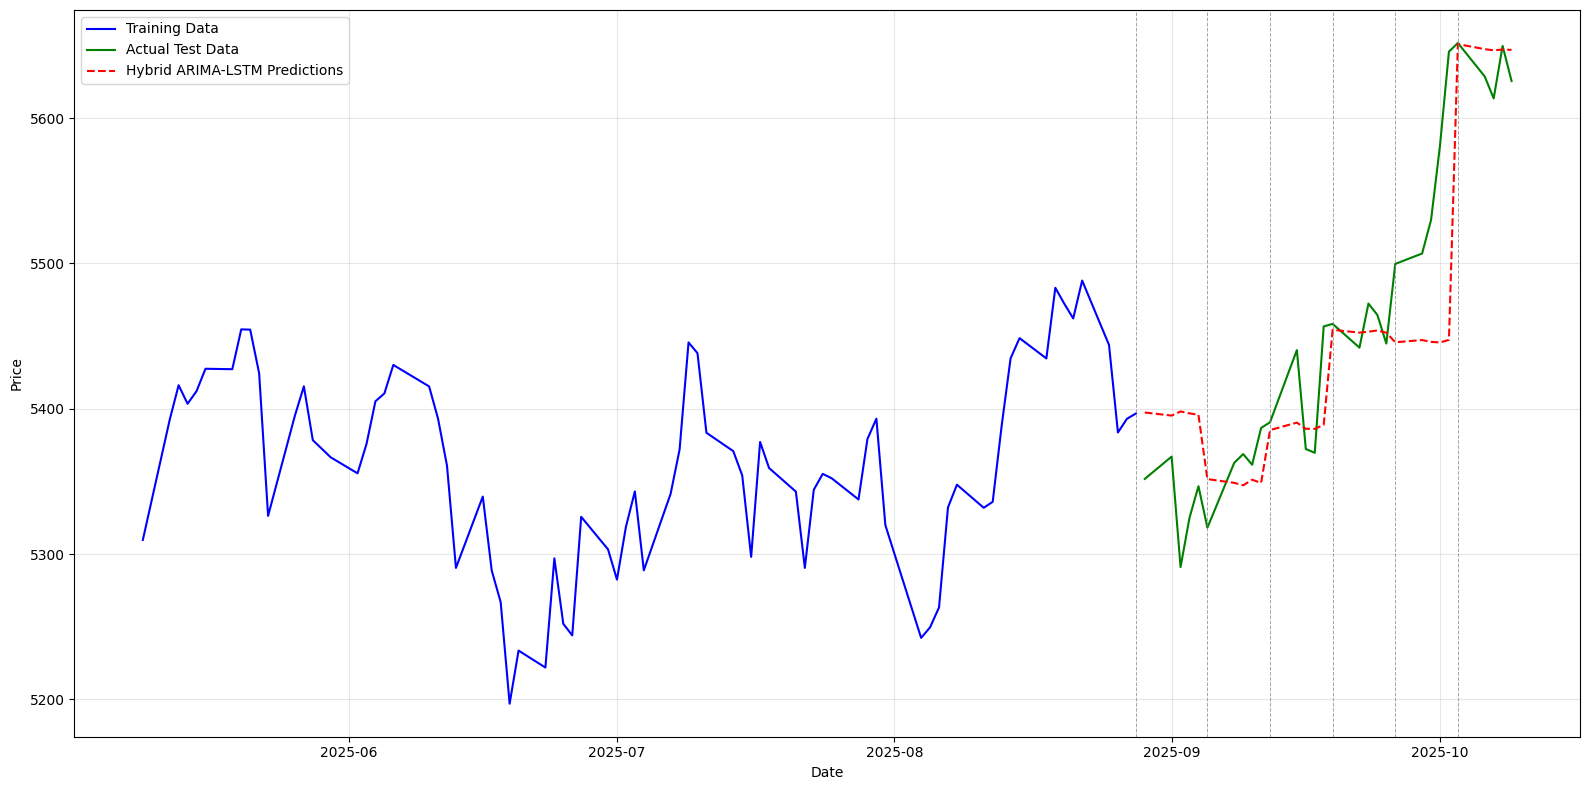

In [10]:
# ============================================
# 8. VISUALIZATION 
# ============================================

print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Determine date range for last 5 months (matching LSTM code)
end_date_plot = test_ts.index.max()
start_date_plot = end_date_plot - pd.DateOffset(months=5)

# Filter data for plotting (using DataFrame format to match LSTM code)
# Convert Series to DataFrame for consistency
train_data_plot = pd.DataFrame({'STOXX50_Close': train_ts})
train_data_plot = train_data_plot[train_data_plot.index >= start_date_plot]

actual_test_data_plot = pd.DataFrame({'STOXX50_Close': test_ts})
actual_test_data_plot = actual_test_data_plot[actual_test_data_plot.index >= start_date_plot]

predicted_data_plot = comparison_df[comparison_df.index >= start_date_plot]

# Create plot (matching LSTM style)
plt.figure(figsize=(16, 8))

# Plot training data (blue)
plt.plot(train_data_plot.index, train_data_plot['STOXX50_Close'], 
         label='Training Data', color='blue', linewidth=1.5)

# Plot actual test data (green)
plt.plot(actual_test_data_plot.index, actual_test_data_plot['STOXX50_Close'], 
         label='Actual Test Data', color='green', linewidth=1.5)

# Plot hybrid predictions (red dashed) - matching LSTM style
plt.plot(predicted_data_plot.index, predicted_data_plot['ARIMA_LSTM_Predicted'], 
         label='Hybrid ARIMA-LSTM Predictions', color='red', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split (matching LSTM style)
plt.axvline(x=train_ts.index[-1], color='gray', 
            linestyle='--', linewidth=0.7, alpha=0.7)

# Add block boundaries (matching LSTM style)
for i in range(1, num_test_blocks):
    block_boundary = test_ts.index[i * forecast_horizon]
    plt.axvline(x=block_boundary, color='gray', linestyle='--', 
                alpha=0.7, linewidth=0.7)

plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [11]:
# ============================================
# 9. FINAL SUMMARY
# ============================================

print(f"\n{'='*60}")
print("HYBRID ARIMA-LSTM FORECASTING COMPLETE (WITH HYPERPARAMETER TUNING)")
print(f"{'='*60}")

print(f"\nModel Configuration:")
print(f"  ARIMA: ({best_p},{d},{best_q})")
print(f"  LSTM (tuned on residuals): {lstm_units} units, dropout={dropout_rate}, seq_length={seq_length}")

print(f"\nForecasting Strategy:")
print(f"  - Recursive retraining with {forecast_horizon}-day blocks")
print(f"  - {num_test_blocks} blocks forecasted ({len(actuals)} days total)")
print(f"  - Hybrid = ARIMA_forecast + LSTM_residual_forecast")

print(f"\nHyperparameter Tuning:")
print(f"  - Method: Simple 80/20 hold-out validation")
print(f"  - Grid: {len(hyperparameter_grid['lstm_units'])}×{len(hyperparameter_grid['dropout_rate'])}×{len(hyperparameter_grid['seq_length'])} = {len(hyperparameter_grid['lstm_units']) * len(hyperparameter_grid['dropout_rate']) * len(hyperparameter_grid['seq_length'])} combinations")
print(f"  - Best validation RMSE: {best_val_rmse:.6f}")

print(f"\nForecasting Results:")
print(f"  Total forecast days: {len(actuals)}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")

print(f"\nOutput Files:")
print(f"  - arima_lstm.csv (predictions vs actuals)")
print(f"  - Can compare with arima.csv and lstm.csv from individual models")
#print(f"  - Also compare with hybrid_arima_lstm.csv (without tuning)")

print(f"\nKey Features:")
print(f"  1. ARIMA captures linear patterns and trends")
print(f"  2. LSTM tuned specifically on ARIMA residuals")
print(f"  3. Hyperparameters tuned with 80/20 hold-out validation")
print(f"  4. Combined model leverages strengths of both approaches")
print(f"  5. Recursive retraining mimics real-world forecasting")


HYBRID ARIMA-LSTM FORECASTING COMPLETE (WITH HYPERPARAMETER TUNING)

Model Configuration:
  ARIMA: (3,1,2)
  LSTM (tuned on residuals): 32 units, dropout=0.5, seq_length=132

Forecasting Strategy:
  - Recursive retraining with 5-day blocks
  - 6 blocks forecasted (30 days total)
  - Hybrid = ARIMA_forecast + LSTM_residual_forecast

Hyperparameter Tuning:
  - Method: Simple 80/20 hold-out validation
  - Grid: 2×2×3 = 12 combinations
  - Best validation RMSE: 0.072821

Forecasting Results:
  Total forecast days: 30
  RMSE: 59.62
  MAE:  41.07

Output Files:
  - arima_lstm.csv (predictions vs actuals)
  - Can compare with arima.csv and lstm.csv from individual models

Key Features:
  1. ARIMA captures linear patterns and trends
  2. LSTM tuned specifically on ARIMA residuals
  3. Hyperparameters tuned with 80/20 hold-out validation
  4. Combined model leverages strengths of both approaches
  5. Recursive retraining mimics real-world forecasting
